In [2]:
# loading the data

import pandas as pd

df = pd.read_csv("mobile_price_classification.csv")

# loot at the first few samples
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


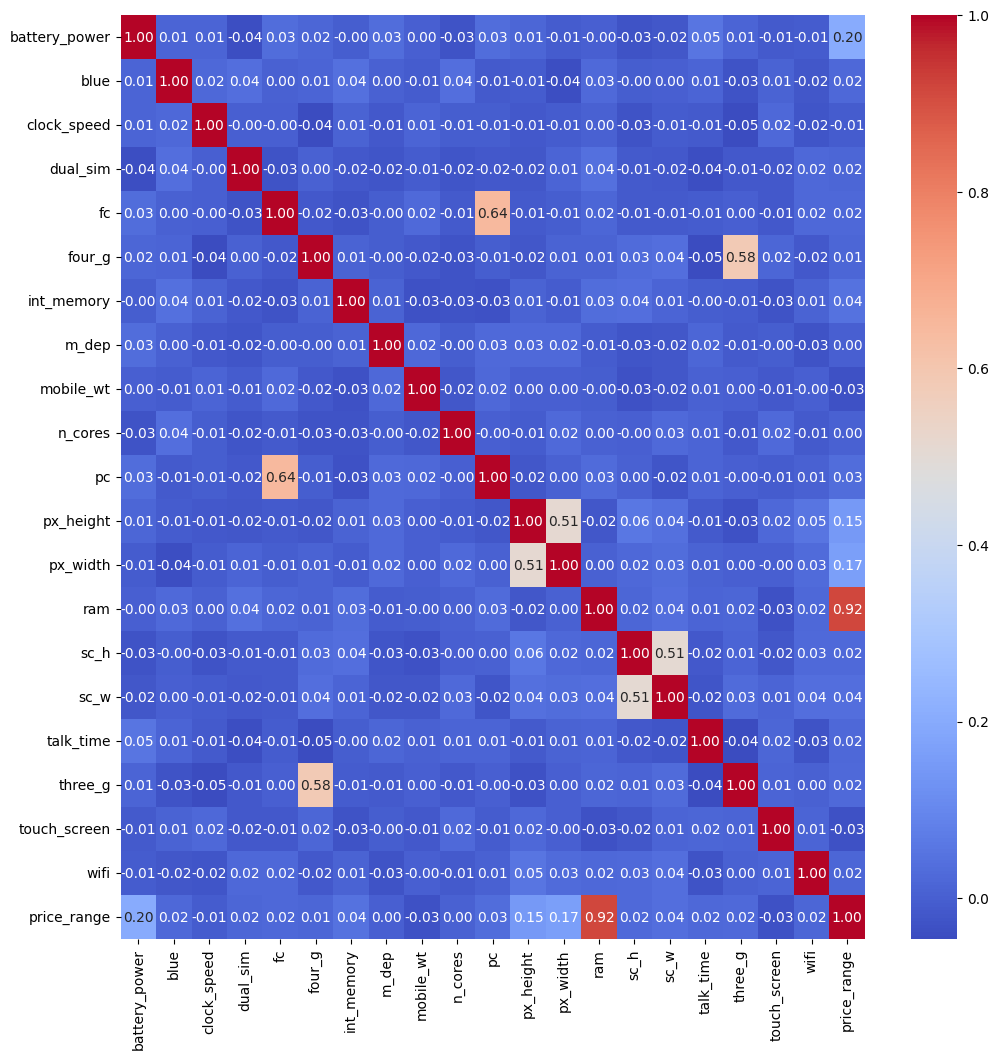

In [6]:
# correlation heatmap to show which features that correlate with the target

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,12))
sns.heatmap(df.corr(),annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [7]:
# check number of missing values 

df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [11]:
# check number of duplicated values

print(df.duplicated().sum())

0


In [12]:
# info about the data

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

In [13]:
# define features and target

X = df.drop('price_range', axis=1)
y = df["price_range"]

In [14]:
# # train test split

from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# # scale features

from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

In [17]:
# # building the base KNN model

from sklearn.neighbors import KNeighborsClassifier
# # running a baseline model with a random k = 5

# # initialize the model
# knn = KNeighborsClassifier(n_neighbors=5)

# # fit the model
# knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [18]:
# # make predictions
# y_pred = knn.predict(X_test_scaled) 

# # check results

from sklearn.metrics import accuracy_score, classification_report
# print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
# print(f"Classification_report: \n{classification_report(y_test, y_pred)}")

Accuracy: 0.53
Classification_report: 
              precision    recall  f1-score   support

           0       0.70      0.72      0.71       105
           1       0.34      0.45      0.39        91
           2       0.35      0.37      0.36        92
           3       0.81      0.54      0.65       112

    accuracy                           0.53       400
   macro avg       0.55      0.52      0.53       400
weighted avg       0.57      0.53      0.54       400



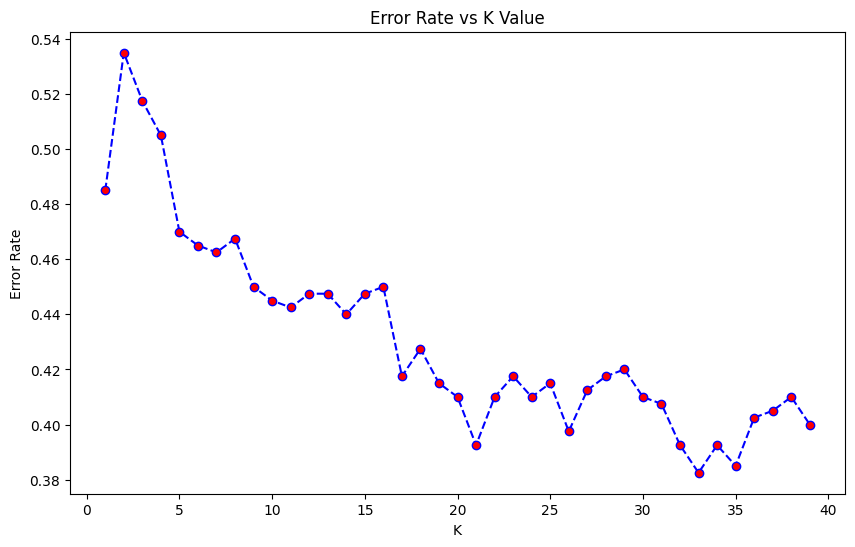

In [20]:
# # Using the Elbow Method

import numpy as np

# error_rate = []

# for i in range(1, 40):
#     knn = KNeighborsClassifier(n_neighbors=i)
#     knn.fit(X_train_scaled, y_train)
#     y_pred_i = knn.predict(X_test_scaled)
#     error_rate.append(np.mean(y_pred_i != y_test))  # average of where predictions don't match y_test

# # plotting the results
# plt.figure(figsize=(10, 6))
# plt.plot(range(1, 40), error_rate, color='blue', linestyle='dashed', marker='o', markerfacecolor='red')
# plt.title("Error Rate vs K Value")
# plt.xlabel("K")
# plt.ylabel("Error Rate")
# plt.show()

In [31]:
# selecting top features that correlate with the target and removing noise

corr_with_target = df.corr().loc[:, "price_range"]
corr_with_target = corr_with_target[corr_with_target.abs() >= 0.1]

top_features = corr_with_target.drop('price_range').index
print(top_features)

Index(['battery_power', 'px_height', 'px_width', 'ram'], dtype='str')


In [33]:
# define features and target according to the engineered features

X = df[top_features]
y= df["price_range"]

# train test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [34]:
# scaling the features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

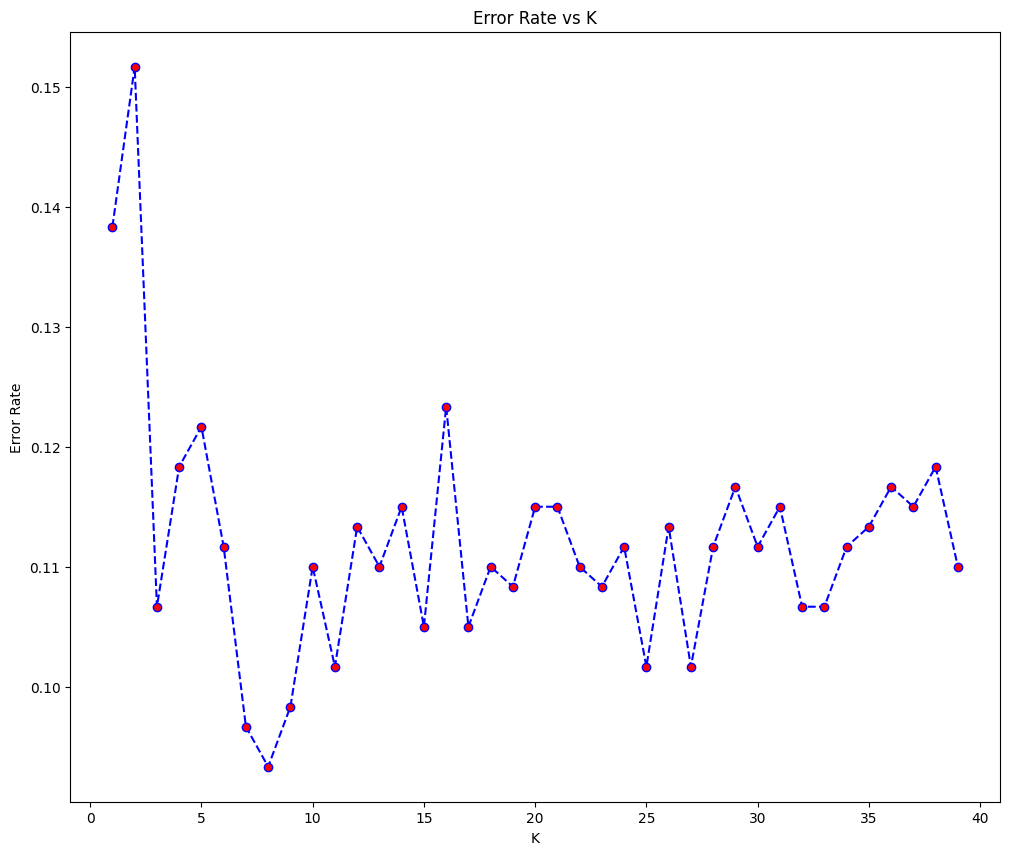

In [37]:
# using the elbow method to get the optimum value of k

error_rate = []

for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    y_pred_i = knn.predict(X_test_scaled)
    error_rate.append(np.mean(y_pred_i != y_test))

# plotting the results
plt.figure(figsize=(12, 10))
plt.plot(range(1, 40), error_rate, color='blue', linestyle='dashed', marker='o', markerfacecolor='red')
plt.title("Error Rate vs K")
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.show()

In [39]:
# building the KNN model using the optimal value of k = 11 gotten from the elbow diagram

# initialize the model
knn = KNeighborsClassifier(n_neighbors=11)

# fit the model
knn.fit(X_train_scaled, y_train)

# make predictions
y_pred = knn.predict(X_test_scaled)

# check results
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Classification Report: \n{classification_report(y_test, y_pred)}")

Accuracy: 0.90
Classification Report: 
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       151
           1       0.85      0.91      0.88       146
           2       0.84      0.84      0.84       148
           3       0.95      0.89      0.92       155

    accuracy                           0.90       600
   macro avg       0.90      0.90      0.90       600
weighted avg       0.90      0.90      0.90       600



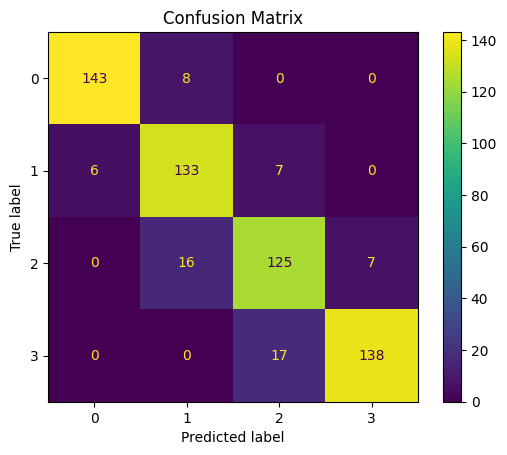

In [41]:
# confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()